In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from itertools import combinations

tickers = ['KO', 'PEP', 'PG', 'CL', 'KMB', 'GIS', 'CPB', 'HSY', 'MKC', 'SJM']

data = yf.download(tickers, start='2020-01-01', end='2024-01-01')
prices = data['Close']

print(prices.head())
print(prices.shape)


[*********************100%***********************]  10 of 10 completed

Ticker             CL        CPB        GIS         HSY         KMB  \
Date                                                                  
2020-01-02  58.424858  38.416264  41.103436  123.323250  107.024910   
2020-01-03  58.339081  38.368721  40.953617  124.436890  106.993385   
2020-01-06  58.742180  38.432110  41.466137  123.845840  107.229759   
2020-01-07  57.935959  38.456043  41.182274  124.085678  107.135216   
2020-01-08  59.411163  37.785717  41.773640  125.105072  108.175278   

Ticker             KO        MKC         PEP          PG        SJM  
Date                                                                 
2020-01-02  45.141262  73.798416  110.945152  104.735359  82.197456  
2020-01-03  44.894981  74.974571  110.789955  104.030945  82.318184  
2020-01-06  44.878578  75.423889  111.214699  104.175224  83.460892  
2020-01-07  44.533806  74.128792  109.466614  103.530243  82.285973  
2020-01-08  44.615891  73.732338  110.030235  103.971542  83.130951  
(1006, 10)


In [2]:
results = []

for stock1, stock2 in combinations(tickers, 2):
    p_value = coint(prices[stock1], prices[stock2])[1]
    results.append((stock1, stock2, p_value))

results_df = pd.DataFrame(results, columns=['Stock1', 'Stock2', 'P-Value'])
results_df = results_df.sort_values('P-Value')

print(results_df.head(10))


   Stock1 Stock2   P-Value
32    KMB    HSY  0.003196
30    KMB    GIS  0.003203
34    KMB    SJM  0.003364
33    KMB    MKC  0.003569
31    KMB    CPB  0.007050
27     CL    HSY  0.030119
29     CL    SJM  0.035059
6      KO    HSY  0.035961
26     CL    CPB  0.043929
25     CL    GIS  0.046562


In [ ]:
import requests

url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv"
sp500 = pd.read_csv(url)
tickers = sp500['Symbol'].tolist()
tickers = [t.replace('.', '-') for t in tickers]

print(f"Total tickers: {len(tickers)}")
print(tickers[:10])

Total tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [10]:
data = yf.download(tickers, start='2020-01-01', end='2024-01-01', auto_adjust=True)
prices = data['Close']

prices = prices.dropna(axis=1, thresh=int(len(prices) *.95))

print(f"Downloaded {prices.shape[1]} tickers with sufficient data.")
print(f"Data range: {prices.index[0]} to {prices.index[-1]}")

[***************       31%                       ]  158 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
[***************       32%                       ]  159 of 503 completed$GEV: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
[**********************51%                       ]  257 of 503 completed$SOLV: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
[**********************63%*****                  ]  315 of 503 completed$FDXF: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
[**********************85%****************       ]  430 of 50

Downloaded 485 tickers with sufficient data.
Data range: 2020-01-02 00:00:00 to 2023-12-29 00:00:00


In [11]:
clean_tickers = prices.columns.tolist()
log_prices = np.log(prices)

results = []
total = len(list(combinations(clean_tickers, 2)))
count = 0

for stock1, stock2 in combinations(clean_tickers, 2):
    count += 1
    if count % 5000 == 0:
        print(f"Progress: {count}/{total} pairs tested ({100*count/total:.1f}%)")

    try:
        p_value = coint(log_prices[stock1], log_prices[stock2])[1]
        if p_value < 0.001: 
            results.append((stock1, stock2, p_value))
    except:
        pass

results_df = pd.DataFrame(results, columns=['Stock1', 'Stock2', 'P-Value'])
results_df = results_df.sort_values('P-Value'),reset_index(drop=True)

print(f"\nFound {len(results_df)} cointegrated pairs with p-value < 0.001")
print(results_df.head(20))


Progress: 5000/117370 pairs tested (4.3%)
Progress: 10000/117370 pairs tested (8.5%)
Progress: 15000/117370 pairs tested (12.8%)
Progress: 20000/117370 pairs tested (17.0%)
Progress: 25000/117370 pairs tested (21.3%)
Progress: 30000/117370 pairs tested (25.6%)
Progress: 35000/117370 pairs tested (29.8%)
Progress: 40000/117370 pairs tested (34.1%)
Progress: 45000/117370 pairs tested (38.3%)
Progress: 50000/117370 pairs tested (42.6%)
Progress: 55000/117370 pairs tested (46.9%)
Progress: 60000/117370 pairs tested (51.1%)
Progress: 65000/117370 pairs tested (55.4%)
Progress: 70000/117370 pairs tested (59.6%)
Progress: 75000/117370 pairs tested (63.9%)
Progress: 80000/117370 pairs tested (68.2%)
Progress: 85000/117370 pairs tested (72.4%)
Progress: 90000/117370 pairs tested (76.7%)
Progress: 95000/117370 pairs tested (80.9%)
Progress: 100000/117370 pairs tested (85.2%)
Progress: 105000/117370 pairs tested (89.5%)
Progress: 110000/117370 pairs tested (93.7%)
Progress: 115000/117370 pairs te

NameError: name 'reset_index' is not defined

In [12]:
results_df = pd.DataFrame(results, columns=['Stock1', 'Stock2', 'P-Value'])
results_df = results_df.sort_values('P-Value').reset_index(drop=True)

print(f"Found {len(results_df)} pairs with p-value < 0.001")
print(results_df.head(20))

Found 495 pairs with p-value < 0.001
   Stock1 Stock2   P-Value
0     BDX   MDLZ  0.000001
1     AWK   RVTY  0.000002
2     NUE   TRGP  0.000002
3    JBHT    LOW  0.000002
4     APA    EOG  0.000003
5     CNP    ELV  0.000004
6     EQT   TRGP  0.000004
7     DGX   NDSN  0.000005
8    BKNG    CRH  0.000005
9     BDX    BRO  0.000006
10    AWK    TGT  0.000007
11    DGX   JBHT  0.000007
12   TRGP    UNH  0.000007
13    APA    WRB  0.000007
14    DGX     MS  0.000008
15    ADI    YUM  0.000009
16    BDX    GWW  0.000010
17    CRH      V  0.000010
18    BDX     KO  0.000011
19    BDX    MAR  0.000013


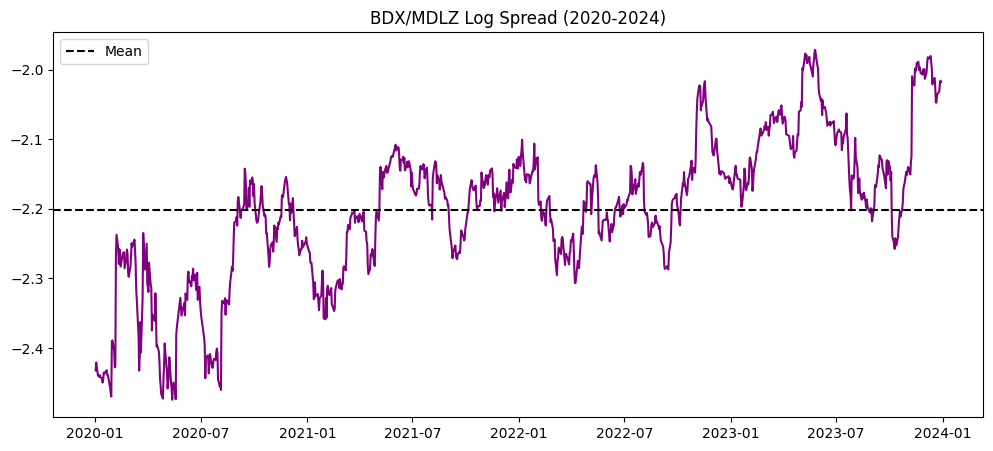

In [13]:
log_prices_bdx = np.log(prices[['BDX', 'MDLZ']])

X = sm.add_constant(log_prices_bdx['BDX'])
model = sm.OLS(log_prices_bdx['MDLZ'], X).fit()
hedge_ratio = model.params['BDX']

spread = log_prices_bdx['MDLZ'] - hedge_ratio * log_prices_bdx['BDX']

plt.figure(figsize=(12, 5))
plt.plot(spread, color='purple')
plt.axhline(spread.mean(), color='black', linestyle='--', label='Mean')
plt.title('BDX/MDLZ Log Spread (2020-2024)')
plt.legend()
plt.show()

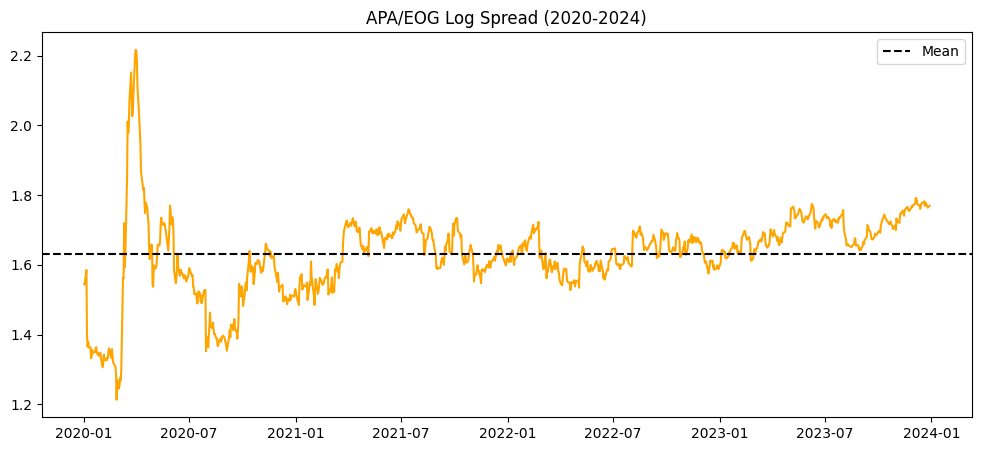

In [15]:
log_prices_oil = np.log(prices[['APA', 'EOG']])

X = sm.add_constant(log_prices_oil['APA'])
model = sm.OLS(log_prices_oil['EOG'], X).fit()
hedge_ratio = model.params['APA']

spread = log_prices_oil['EOG'] - hedge_ratio * log_prices_oil['APA']

plt.figure(figsize=(12, 5))
plt.plot(spread, color='orange')
plt.axhline(spread.mean(), color='black', linestyle='--', label='Mean')
plt.title('APA/EOG Log Spread (2020-2024)')
plt.legend()
plt.show()

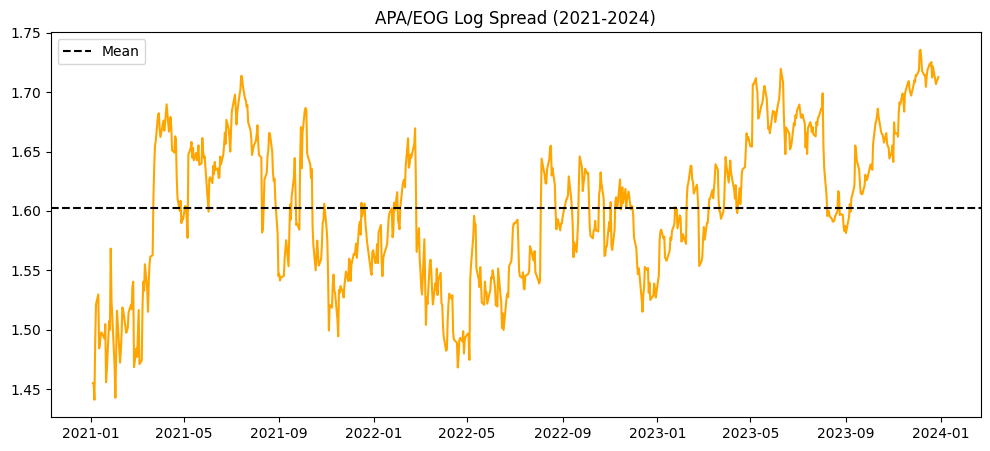

P-value (2021-2024): 0.0088


In [ ]:
log_prices_oil2 = np.log(prices[['APA', 'EOG']]['2021-01-01':])

X = sm.add_constant(log_prices_oil2['APA'])
model = sm.OLS(log_prices_oil2['EOG'], X).fit()
hedge_ratio = model.params['APA']

spread = log_prices_oil2['EOG'] - hedge_ratio * log_prices_oil2['APA']

plt.figure(figsize=(12, 5))
plt.plot(spread, color='orange')
plt.axhline(spread.mean(), color='black', linestyle='--', label='Mean')
plt.title('APA/EOG Log Spread (2021-2024)')
plt.legend()
plt.show()

p_val = coint(log_prices_oil2['APA'], log_prices_oil2['EOG'])[1]
print(f"P-value (2021-2024): {p_val:.4f}")

In [17]:
live_data = yf.download(['BDX', 'MDLZ'], start='2024-01-01', end=pd.Timestamp.today().strftime('%Y-%m-%d'))
live_prices = live_data['Close']

log_live = np.log(live_prices)

log_formation = np.log(prices[['BDX', 'MDLZ']])
X = sm.add_constant(log_formation['BDX'])
model = sm.OLS(log_formation['MDLZ'], X).fit()
hedge_ratio = model.params['BDX']

formation_spread = log_formation['MDLZ'] - hedge_ratio * log_formation['BDX']
spread_mean = formation_spread.mean()
spread_std = formation_spread.std()

live_spread = log_live['MDLZ'] - hedge_ratio * log_live['BDX']
live_zscore = (live_spread - spread_mean) / spread_std

print(f"Current Z-Score: {live_zscore.iloc[-1]:.4f}")
print(f"Current Signal: ", end="")
if live_zscore.iloc[-1] > 2:
    print("SHORT MDLZ, LONG BDX")
elif live_zscore.iloc[-1] < -2:
    print("LONG MDLZ, SHORT BDX")
else:
    print("FLAT - no position")

[*********************100%***********************]  2 of 2 completed

Current Z-Score: 3.3041
Current Signal: SHORT MDLZ, LONG BDX


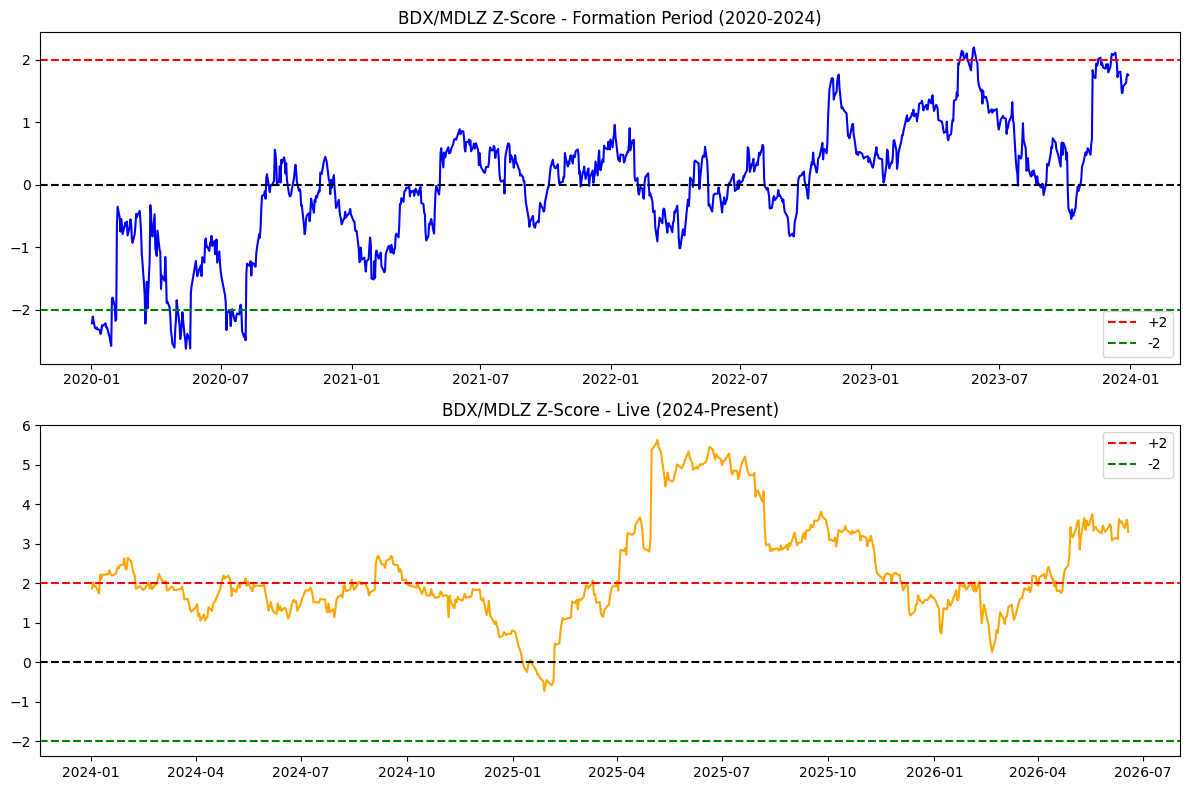

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

historical_zscore = (formation_spread - spread_mean) / spread_std
axes[0].plot(historical_zscore, color='blue')
axes[0].axhline(2, color='red', linestyle='--', label='+2')
axes[0].axhline(-2, color='green', linestyle='--', label='-2')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('BDX/MDLZ Z-Score - Formation Period (2020-2024)')
axes[0].legend()

axes[1].plot(live_zscore, color='orange')
axes[1].axhline(2, color='red', linestyle='--', label='+2')
axes[1].axhline(-2, color='green', linestyle='--', label='-2')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('BDX/MDLZ Z-Score - Live (2024-Present)')
axes[1].legend()

plt.tight_layout()
plt.show()